In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plotting style
sns.set(style="whitegrid")

In [2]:
# Column definitions for CMAPSS FD001
index_cols = ['unit_number', 'time_cycles']
setting_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols = ['s_{}'.format(i) for i in range(1, 22)]
all_cols = index_cols + setting_cols + sensor_cols

# Loading the training data from Kaggle input path
input_path = '/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt'
raw_data = pd.read_csv(input_path, sep='\s+', header=None, names=all_cols)

print(f"Dataset Dimensions: {raw_data.shape}")
raw_data.head()

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_17/1769343597.py:9: SyntaxWarning: invalid escape sequence '\s'
  raw_data = pd.read_csv(input_path, sep='\s+', header=None, names=all_cols)


Dataset Dimensions: (20631, 26)


,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# Calculate maximum cycles per engine to derive Remaining Useful Life (RUL)
max_cycles = raw_data.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']
train_df = raw_data.merge(max_cycles, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']

# Labeling logic for 3-class classification
# 0: Healthy (RUL > 125), 1: Warning (50 < RUL <= 125), 2: Failure (RUL <= 50)
def categorize_health(rul):
    if rul <= 50:
        return 2
    elif rul <= 125:
        return 1
    else:
        return 0

train_df['health_state'] = train_df['RUL'].apply(categorize_health)

# Drop intermediate columns
train_df.drop(['max_cycle', 'RUL'], axis=1, inplace=True)

/tmp/ipykernel_17/167575243.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='health_state', data=train_df, palette='magma')


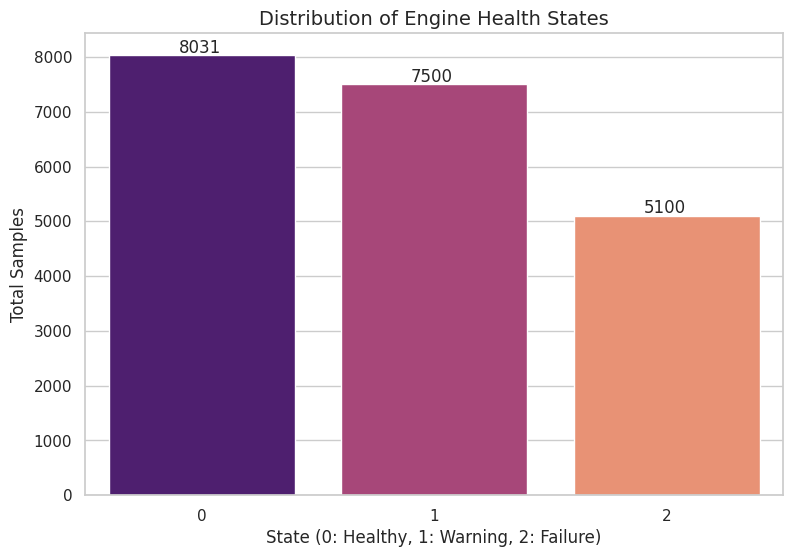

In [4]:
plt.figure(figsize=(9, 6))
ax = sns.countplot(x='health_state', data=train_df, palette='magma')
plt.title('Distribution of Engine Health States', fontsize=14)
plt.xlabel('State (0: Healthy, 1: Warning, 2: Failure)')
plt.ylabel('Total Samples')

# Adding count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

plt.show()

In [5]:
# Selecting sensor readings as independent variables
X = train_df[sensor_cols]
y = train_df['health_state']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=2000, multi_class='multinomial'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7)
}

performance_summary = {}

# Iterate through models
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    predictions = clf.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, predictions)
    performance_summary[name] = acc
    
    print(f"--- {name} Performance ---")
    print(f"Accuracy: {acc:.2%}")
    print(classification_report(y_test, predictions, target_names=['Healthy', 'Warning', 'Failure']))
    print("-" * 30)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Logistic Regression Performance ---
Accuracy: 72.16%
              precision    recall  f1-score   support

     Healthy       0.72      0.74      0.73      1607
     Warning       0.62      0.62      0.62      1500
     Failure       0.88      0.84      0.86      1020

    accuracy                           0.72      4127
   macro avg       0.74      0.73      0.74      4127
weighted avg       0.72      0.72      0.72      4127

------------------------------
--- Random Forest Performance ---
Accuracy: 72.09%
              precision    recall  f1-score   support

     Healthy       0.69      0.79      0.74      1607
     Warning       0.63      0.58      0.60      1500
     Failure       0.91      0.82      0.86      1020

    accuracy                           0.72      4127
   macro avg       0.74      0.73      0.73      4127
weighted avg       0.72      0.72      0.72      4127

------------------------------
--- K-Nearest Neighbors Performance ---
Accuracy: 69.78%
           

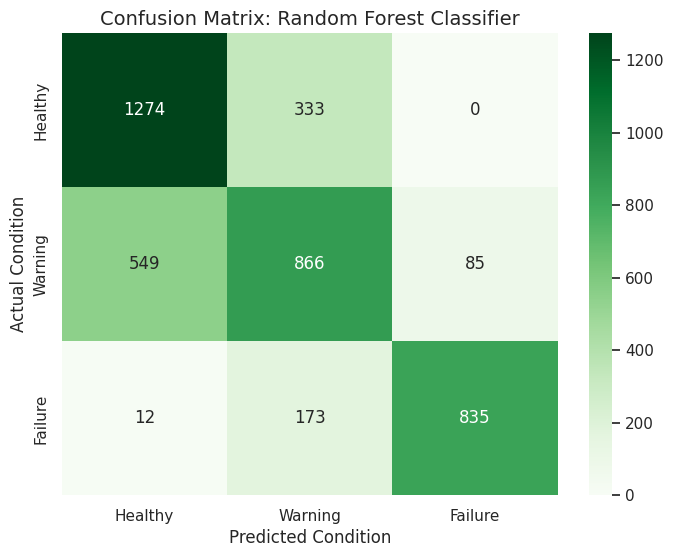

In [7]:
# Visualizing the best performing model (Random Forest)
rf_model = classifiers["Random Forest"]
y_pred_rf = rf_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Warning', 'Failure'],
            yticklabels=['Healthy', 'Warning', 'Failure'])
plt.title('Confusion Matrix: Random Forest Classifier', fontsize=14)
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.show()

/tmp/ipykernel_17/17925680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_ranking.values[:10], y=feature_ranking.index[:10], palette='rocket')


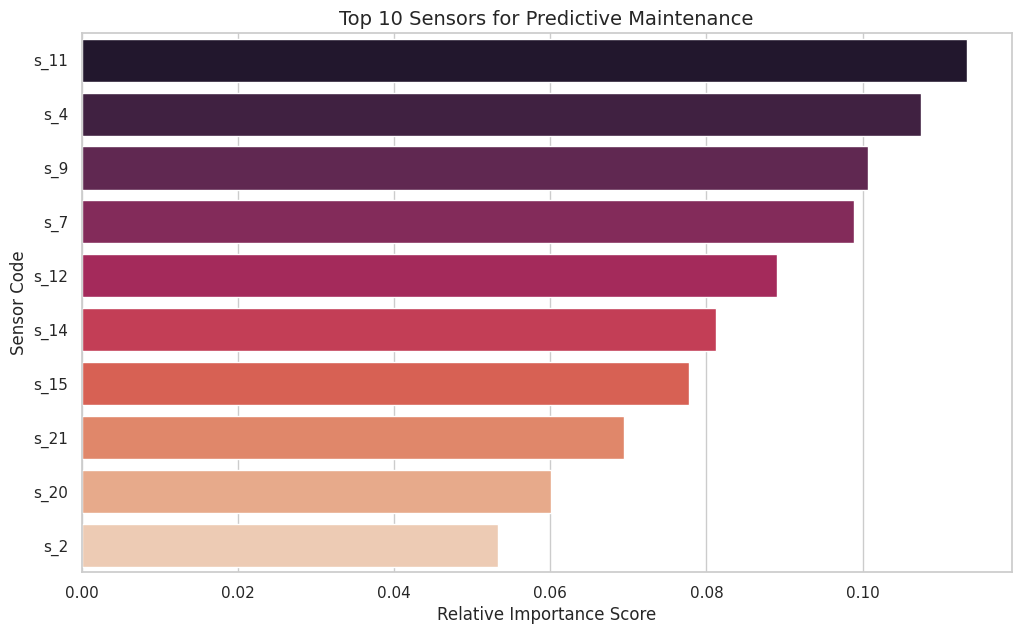

In [8]:
# Extracting importance from Random Forest
importances = rf_model.feature_importances_
feature_ranking = pd.Series(importances, index=sensor_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_ranking.values[:10], y=feature_ranking.index[:10], palette='rocket')
plt.title('Top 10 Sensors for Predictive Maintenance', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Sensor Code')
plt.show()